Intro to Python: Final Project

1. Create the following variables and assign values to each one:
- age (integer type)
- BMI (float type)
- gender (string type)
- stroke status (boolean type)

Print the type of each variable afterwards to ensure their type matches the listed specified types.

In [32]:
age = 67
bmi = 28.4
gender = "female"
had_stroke = True

print(type(age), type(bmi), type(gender), type(had_stroke))

<class 'int'> <class 'float'> <class 'str'> <class 'bool'>


2. Print statements that include the following data: the patient's age, gender, as well as whether they had a stroke. Make sure that the all sentences are meaningful and can be understood by a layman with no explanation.

In [33]:
print(f"Patient is {age} years old.")
print(f"Patient is {gender}.")
if had_stroke:
    print("Patient suffered from a stroke.")
else:
    print("Patient has not suffered from a stroke.")

Patient is 67 years old.
Patient is female.
Patient suffered from a stroke.


3. Create a list named "mistakes" with the following inconsistent gender labels stored in them: " female", "FEMALE", and "f3male". Once you've created the list named "mistakes", append a new string named "fe male" to it. Print the first item, the last item, and both of the middle items from the "mistakes" list. Clean this list up using string methods such that all entries now read "female" and print the corrections.

In [34]:
mistakes = [" female", "FEMALE", "f3male"]
mistakes.append("fe male")

print(mistakes[0].strip())
print(mistakes[1].lower())
print(mistakes[2].replace("3", "e"))
print(mistakes[3].replace(" ", ""))

female
female
female
female


4. Create a tuple including your first name, age, and whether you've had a stroke using the format of your previously specified variables and print the 3 variables in one line. Why might tuples be used for storing patient records?

In [35]:
patient = ("Deborah", 67, True)
name, age, had_stroke = patient
print(name, age, had_stroke)


Deborah 67 True


5. Set your age variable to 70 years old and create a hypertension variable set to True. Write a boolean expression that flags high stroke risk, store this risk assessment in a variable named "is_high_risk", and print the risk status in a statement that's understandable for laymen.

Reminder: A patient is considered high risk if they're over the age of 65 and have hypertension.

In [36]:
age = 70
has_hypertension = True

is_high_risk = age > 65 and has_hypertension

print(f"Patient's high risk status: ", is_high_risk)

Patient's high risk status:  True


6. Let's expand on risk status using the same values for age and hypertension as the previous question. With the same variables for age and hypertension status, write conditional statements such that a patient who is over 65 years old and has hypertension has a "High" stroke risk, a patient who is only either over 65 years old or has hypertension has a "Moderate" stroke risk, and a patient who is 65 or younger and has no hypertension has a "Low" stroke risk. Store the risk assessment in a variable named "risk" and print the result.

In [37]:
if age > 65 and has_hypertension:
    risk = "High"
elif age > 65:
    risk = "Moderate"
else:
    risk = "Low"

print(risk)

High


7. Create a patient list with the following information stored:
- Patient 1: female and has had a stroke
- Patient 2: male and has had a stroke
- Patient 3: male and has not had a stroke
- Patient 4: female and has not had a stroke

Count and print the number of patients in this list who have suffered from a stroke using a for loop.

In [38]:
patient_list = [{gender: "female", had_stroke: True}, {gender: "male", had_stroke: True}, {gender: "male", had_stroke: False}, {gender: "female", had_stroke: False}]

stroke_count = 0
for patient in patient_list:
    if patient[had_stroke] == True:
        stroke_count += 1

print(stroke_count)

2


8. Import the numpy, pandas, and matplotlib.pyplot packages.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

9. Create a function to determine the stroke rate of patients.

In [40]:
def calculate_stroke_rate(data):
    return data["stroke"].mean()

10. Load the stroke dataset and explore it. Which variables are numeric and which are categorical? Generate descriptive statistics for the three ratio variables in this datatset. Which variable is missing data and how many empty cells are there in this variable? Create an age histogram and a scatterplot of age by average glucose level.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
--- Numeric Statistics ---
                age  avg_glucose_level          bmi
count   5110.000000        5110.000000  4909.000000
mean      43.226614       

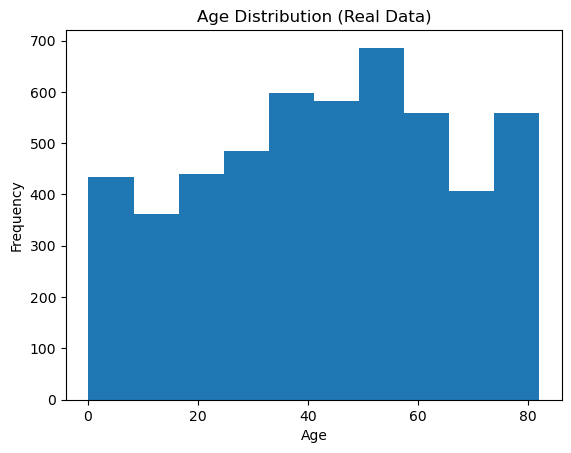

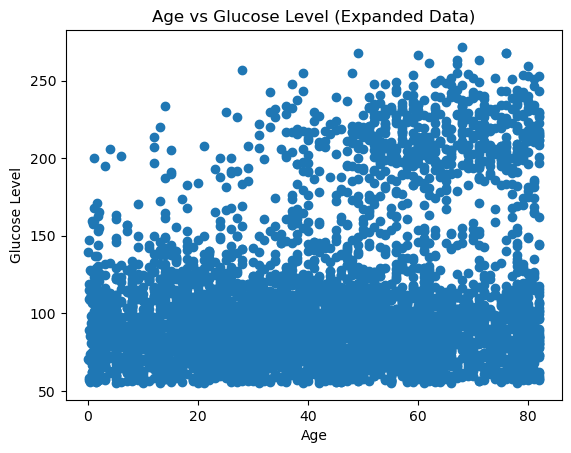

In [62]:
real_dataset = pd.read_csv("C:/Users/debor/Downloads/healthcare-dataset-stroke-data.csv")
real_dataset.head()
real_dataset.info()
real_dataset.describe()
real_dataset.isnull().sum()

numeric_summary = real_dataset.agg(
    {
        "age": ["count", "mean", "var", "std", "min", "median", "max", "skew", "kurt"],
        "avg_glucose_level": ["count", "mean", "var", "std", "min", "median", "max", "skew", "kurt"],
        "bmi": ["count", "mean", "var", "std", "min", "median", "max", "skew", "kurt"],
    }
)
print("--- Numeric Statistics ---")
print(numeric_summary)

plt.hist(real_dataset["age"])
plt.title("Age Distribution (Real Data)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.scatter(real_dataset["age"], real_dataset["avg_glucose_level"])
plt.xlabel("Age")
plt.ylabel("Glucose Level")
plt.title("Age vs Glucose Level (Expanded Data)")
plt.show()

11. Compare the number of people who have had a stroke to the number of people who haven't. Use your previously defined function to determine stroke rate within the dataset. Conduct a t-test to see if there is a significant difference in average glucose levels between those who have had a stroke and those who have not. Print the stroke rate by presence of hypertension.

In [ ]:
from scipy.stats import ttest_ind

print(calculate_stroke_rate(real_dataset))

print(ttest_ind(
    real_dataset.loc[real_dataset["stroke"] == 1, "avg_glucose_level"],
    real_dataset.loc[real_dataset["stroke"] == 0, "avg_glucose_level"]
))

print(real_dataset.groupby("hypertension")["stroke"].mean())


0.0487279843444227
0.0487279843444227
TtestResult(statistic=np.float64(9.513352175431471), pvalue=np.float64(2.767810519474146e-21), df=np.float64(5108.0))
TtestResult(statistic=np.float64(9.513352175431471), pvalue=np.float64(2.767810519474146e-21), df=np.float64(5108.0))
hypertension
0    0.039679
1    0.132530
Name: stroke, dtype: float64


12. Generate a new data frame that includes synthetic data for 500 participants. Generate the gender for all participants randomly. To create the other variables, copy-paste the following code into your data frame:

"age": np.random.randint(18, 90, size=n_new),
"hypertension": np.random.choice([0, 1], size=n_new, p=[0.85, 0.15]),
"heart_disease": np.random.choice([0, 1], size=n_new, p=[0.9, 0.1]),
"ever_married": np.random.choice(["Yes", "No"], size=n_new),
"work_type": np.random.choice(
        ["Private", "Self-employed", "Govt_job", "children", "Never_worked"], size=n_new
    ),
"Residence_type": np.random.choice(["Urban", "Rural"], size=n_new),
"avg_glucose_level": np.random.normal(loc=100, scale=30, size=n_new),
"bmi": np.random.normal(loc=28, scale=7, size=n_new),
"smoking_status": np.random.choice(
        ["formerly smoked", "never smoked", "smokes", "Unknown"], size=n_new
    )



In [42]:
np.random.seed(42)  # For reproducibility

n_new = 500  # Number of synthetic patients

synthetic_data = pd.DataFrame({
    "gender": np.random.choice(["Male", "Female"], size=n_new),
    "age": np.random.randint(18, 90, size=n_new),
    "hypertension": np.random.choice([0, 1], size=n_new, p=[0.85, 0.15]),
    "heart_disease": np.random.choice([0, 1], size=n_new, p=[0.9, 0.1]),
    "ever_married": np.random.choice(["Yes", "No"], size=n_new),
    "work_type": np.random.choice(
        ["Private", "Self-employed", "Govt_job", "children", "Never_worked"], size=n_new
    ),
    "Residence_type": np.random.choice(["Urban", "Rural"], size=n_new),
    "avg_glucose_level": np.random.normal(loc=100, scale=30, size=n_new),
    "bmi": np.random.normal(loc=28, scale=7, size=n_new),
    "smoking_status": np.random.choice(
        ["formerly smoked", "never smoked", "smokes", "Unknown"], size=n_new
    )
})
synthetic_data.info()

# Ensure that the average glucose levels are between 50 & 300 and the BMI is between 10 and 60
synthetic_data["avg_glucose_level"] = synthetic_data["avg_glucose_level"].clip(lower=50, upper=300)
synthetic_data["bmi"] = synthetic_data["bmi"].clip(lower=10, upper=60)

# Base probability
base_risk = 0.02

# Increase risk based on age, hypertension, and heart disease
risk_score = (
    base_risk
    + 0.003 * synthetic_data["age"]
    + 0.15 * synthetic_data["hypertension"]
    + 0.20 * synthetic_data["heart_disease"]
)

# Convert to probabilities using a logistic function
prob_stroke = 1 / (1 + np.exp(-risk_score))

# Generate stroke outcomes
synthetic_data["stroke"] = np.random.binomial(1, prob_stroke)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             500 non-null    object 
 1   age                500 non-null    int32  
 2   hypertension       500 non-null    int64  
 3   heart_disease      500 non-null    int64  
 4   ever_married       500 non-null    object 
 5   work_type          500 non-null    object 
 6   Residence_type     500 non-null    object 
 7   avg_glucose_level  500 non-null    float64
 8   bmi                500 non-null    float64
 9   smoking_status     500 non-null    object 
dtypes: float64(2), int32(1), int64(2), object(5)
memory usage: 37.2+ KB


13. Add your randomly generated data to the existing stroke dataset and save it as a separate file named "[LAST NAME]_[First Name]_expanded_stroke_dataset.csv"

In [43]:
df_combined = pd.concat([real_dataset, synthetic_data], ignore_index=True)
df_combined.shape

df_combined.to_csv("C:/Users/debor/Downloads/expanded_stroke_dataset.csv", index=False)

14. Repeat the instructions for the plot creations of part 10 and part 11 using the combined dataset.

0.0944741532976827
TtestResult(statistic=np.float64(5.977115856063174), pvalue=np.float64(2.411180933115726e-09), df=np.float64(5608.0))
hypertension
0    0.083317
1    0.191050
Name: stroke, dtype: float64
Stroke rate (real data): 0.0487279843444227
Stroke rate (combined data): 0.0944741532976827


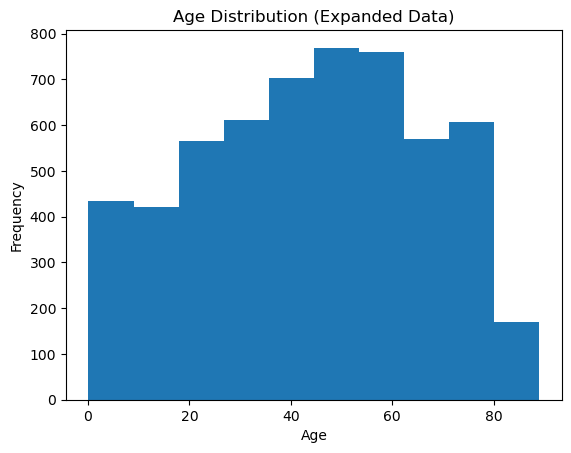

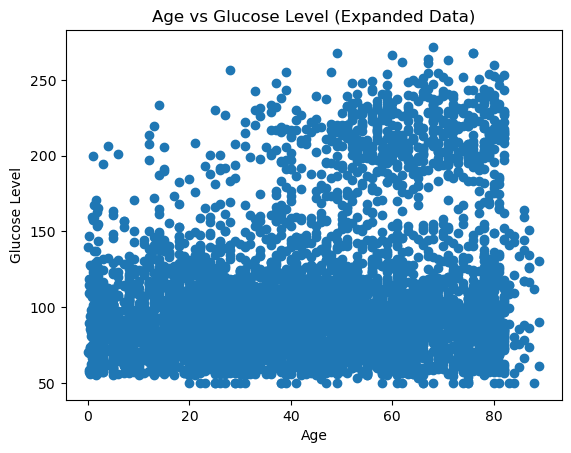

In [66]:
print(calculate_stroke_rate(df_combined))

print(ttest_ind(
    df_combined.loc[df_combined["stroke"] == 1, "avg_glucose_level"],
    df_combined.loc[df_combined["stroke"] == 0, "avg_glucose_level"]
))

print(df_combined.groupby("hypertension")["stroke"].mean())

print("Stroke rate (real data):", calculate_stroke_rate(real_dataset))
print("Stroke rate (combined data):", calculate_stroke_rate(df_combined))

plt.hist(df_combined["age"])
plt.title("Age Distribution (Expanded Data)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.scatter(df_combined["age"], df_combined["avg_glucose_level"])
plt.xlabel("Age")
plt.ylabel("Glucose Level")
plt.title("Age vs Glucose Level (Expanded Data)")
plt.show()

15. Create a correlation matrix showing the relationship between age, BMI, and average glucose level. Generate a statistical model regressing the occurence of stroke on age, hypertension occurence, and heart disease occurence. Generate a second statistical model regressing stroke occurence on the same 3 main effects as well as interaction effects. Compare the two models and determine whether the second model that includes the interaction effects explains significantly more variation in stroke occurence than the main-effects only model.

In [57]:
print(df_combined[["age", "bmi", "avg_glucose_level"]].corr())

import statsmodels.formula.api as sm

model_main = sm.ols(formula = 'stroke ~ age + hypertension + heart_disease', data = df_combined).fit()
print(model_main.summary())

model_interaction = sm.ols(formula = 'stroke ~ age + hypertension + heart_disease + age*hypertension + age*heart_disease + hypertension*heart_disease', data = df_combined).fit()
print(model_interaction.summary())

model_interaction.compare_f_test(model_main)


                        age       bmi  avg_glucose_level
age                1.000000  0.307189           0.220502
bmi                0.307189  1.000000           0.167175
avg_glucose_level  0.220502  0.167175           1.000000
                            OLS Regression Results                            
Dep. Variable:                 stroke   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     119.7
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           4.06e-75
Time:                        20:29:01   Log-Likelihood:                -889.58
No. Observations:                5610   AIC:                             1787.
Df Residuals:                    5606   BIC:                             1814.
Df Model:                           3                                         
Covariance Type:            nonrobust                        

(np.float64(4.977357202096114),
 np.float64(0.0018920454856641094),
 np.float64(3.0))